# DisPerSE runs on DR2 survey mocks

This series of notebooks will investigate the impact of:

 * footprint
 * density-dependent incompleteness (fibre assignment)
 * RSD

on the recovery of cosmic web environments using DisPerSE on DR2 survey mocks. We will do this using mocks that progress over 4 stages:

 * stage 1 - full sky / contigous mock (cosmological redshift)
 * stage 2 - DR2 tiles (all targets, cosmological redshift)
 * stage 3 - stage 2 + fibre assignment with altMTL (cosmological redshift)
 * stage 4 - stage 3 + RSD (observed redshifts)

This notebook reads the mocks and creates catalogues ready for DisPerSE to read.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits, ascii
import astropy.table as table
from astropy.table import unique
import pandas as pd
import desiutil.plots as desiplots
import os

In [2]:
#directory for the original mocks (full sky)
second_gen_sim='/global/cfs/cdirs/desi/cosmosim/SecondGenMocks/AbacusSummit/CutSky/BGS/v0.1/z0.200/'
#directory for cut-sky mocks
second_gen_survey='/global/cfs/cdirs/desi/survey/catalogs/DA2/mocks/SecondGenMocks/AbacusSummitBGS_v2/'

#construct filenames for each of the three types of mocks:
mock=1 #take 1 as an example, can vary between 1 and 25
fname_sim=second_gen_sim+'cutsky_BGS_z0.200_AbacusSummit_base_c000_ph%03d.fits'%(mock)
fname_cutsky=second_gen_survey+'mock%d/pota-BRIGHT.fits'%(mock)
fname_cutsky_altmtl=second_gen_survey+'altmtl%d/kibo-v1/mock%d/LSScats/BGS_BRIGHT_clustering.dat.fits'%(mock,mock)

In [3]:
print(fname_sim)
print(fname_cutsky)
print(fname_cutsky_altmtl)

/global/cfs/cdirs/desi/cosmosim/SecondGenMocks/AbacusSummit/CutSky/BGS/v0.1/z0.200/cutsky_BGS_z0.200_AbacusSummit_base_c000_ph001.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/mocks/SecondGenMocks/AbacusSummitBGS_v2/mock1/pota-BRIGHT.fits
/global/cfs/cdirs/desi/survey/catalogs/DA2/mocks/SecondGenMocks/AbacusSummitBGS_v2/altmtl1/kibo-v1/mock1/LSScats/BGS_BRIGHT_clustering.dat.fits


### Stage 1 mock: Full sky mock

In [4]:
#read mock and header
h=fits.open(fname_sim)
#print(h.info())
header_sim=h[1].header
data_sim=h[1].data
Tb_sim = table.Table(data_sim)
h.close()


We don't need the full sky. Define two sky regions that will be roughly matched to the NGC and SGC. Define a magnitude limited sample to r=19.5.

In [5]:
sim_SGC = ((Tb_sim['RA'] < 40.) | (Tb_sim['RA'] > 330.)) & (Tb_sim['DEC'] > -15) & (Tb_sim['DEC'] < 30) & (Tb_sim['R_MAG_APP'] < 19.5)

In [6]:
sim_NGC = (Tb_sim['RA'] < 270.) & (Tb_sim['RA'] > 120.) & (Tb_sim['DEC'] > -5) & (Tb_sim['DEC'] < 75) & (Tb_sim['R_MAG_APP'] < 19.5)

In [7]:
print(len(Tb_sim))
print(len(Tb_sim[sim_NGC]))
print(len(Tb_sim[sim_SGC]))

64016762
6721191
2260780


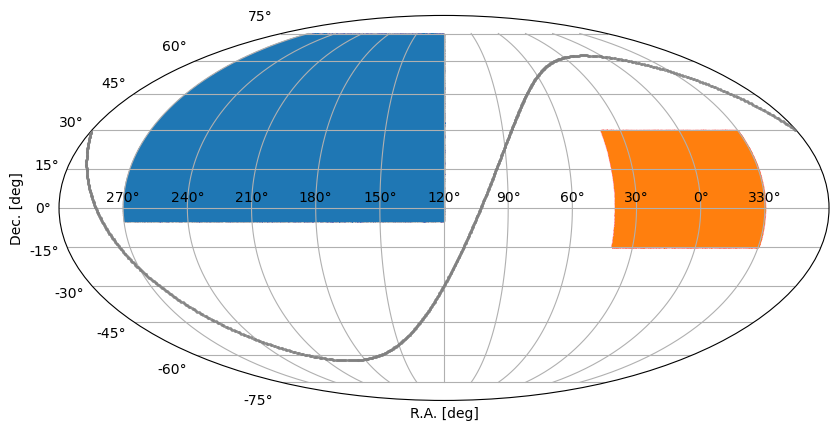

In [8]:
ax = desiplots.init_sky(projection='mollweide', ra_center=120, galactic_plane_color='gray', ecliptic_plane_color=None, ax=None)
ax.scatter(ax.projection_ra(Tb_sim['RA'][sim_NGC]), ax.projection_dec(Tb_sim['DEC'][sim_NGC]), s=0.1, alpha=0.01)
ax.scatter(ax.projection_ra(Tb_sim['RA'][sim_SGC]), ax.projection_dec(Tb_sim['DEC'][sim_SGC]), s=0.1, alpha=0.01)


### Stage 2 mocks: Cut-sky mock to DR2 footprint before fibre assignment (cutsky)

In [9]:
#read mock and header
h=fits.open(fname_cutsky)
#print(h.info())
header_cutsky=h[1].header
data_cutsky=h[1].data
Tb_cutsky_full = table.Table(data_cutsky)
h.close()

This mock has target repeats from different (overlapping) tiles. I.e., the same object can be targeted in more than one tile. If N tiles with object X are included in the DR2 footprint, then this mock will have object X repeated N times. 

Here we will just take one instance of each object, it does not matter what tile we pull it from. 

In [10]:
Tb_cutsky = table.unique(Tb_cutsky_full, keys='TARGETID')

In [11]:
print(len(Tb_cutsky_full), len(Tb_cutsky))

46085616 17197352


Split into NGC and SCG (to be fitted separately) and define magnitude-limited sample to r=19.5

In [12]:
cutsky_NGC = (Tb_cutsky['RA']<300) & (Tb_cutsky['RA']>80) & (Tb_cutsky['R_MAG_APP']<19.5)
cutsky_SGC = ((Tb_cutsky['RA']<80) | (Tb_cutsky['RA'] > 300)) & (Tb_cutsky['R_MAG_APP']<19.5)

In [13]:
print(len(Tb_cutsky), len(Tb_cutsky[cutsky_NGC]), len(Tb_cutsky[cutsky_SGC]))

17197352 6977689 3039317


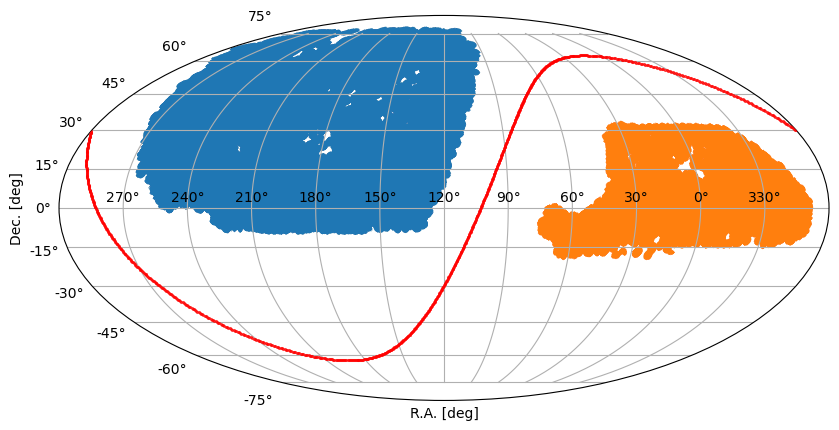

In [14]:
ax = desiplots.init_sky(projection='mollweide', ra_center=120, galactic_plane_color='red', ax=None, ecliptic_plane_color=None)
ax.scatter(ax.projection_ra(Tb_cutsky['RA'][cutsky_NGC]), ax.projection_dec(Tb_cutsky['DEC'][cutsky_NGC]), s=0.01, alpha=0.1)
ax.scatter(ax.projection_ra(Tb_cutsky['RA'][cutsky_SGC]), ax.projection_dec(Tb_cutsky['DEC'][cutsky_SGC]), s=0.01, alpha=0.1)


In [15]:
Tb_cutsky

LOCATION,FIBER,TARGETID,R_MAG_APP,R_MAG_ABS,G_R_REST,G_R_OBS,DEC,RA,TRUEZ,RSDZ,IN_Y5,DESI_TARGET,PRIORITY_INIT,PRIORITY,NUMOBS_MORE,NUMOBS_INIT,BGS_TARGET,MWS_TARGET,SUBPRIORITY,BRICKNAME,OBSCONDITIONS,SCND_TARGET,ZWARN,BRICKID,MASKBITS,NOBS_G,NOBS_R,NOBS_Z,COLLISION,TILEID
int64,int64,int64,float32,float32,float32,float32,float64,float64,float32,float32,int32,int64,int64,int64,int64,int64,int64,int64,float64,str8,int64,int64,int64,int64,int64,int64,int64,int64,bool,int64
9152,4789,1,19.472958,-22.457224,0.9302342,1.6172324,25.558481216430664,270.05364990234375,0.5042778,0.50449157,1,1152921504606846976,2100,2100,2,2,2,0,0.8620084688380503,2700p255,516,0,0,473658,0,6,7,8,False,22471
6446,3056,2,19.463245,-22.520018,1.0171874,1.6929102,26.19740867614746,270.1248474121094,0.5027992,0.50327384,1,1152921504606846976,2100,2100,2,2,2,0,0.797108760630664,2700p262,516,0,0,477550,0,8,8,8,False,24036
8083,4344,3,19.212185,-22.411236,0.91662294,1.6467452,26.073673248291016,270.07965087890625,0.4722926,0.4707914,1,1152921504606846976,2100,2100,2,2,2,0,0.36795875462604466,2701p260,516,0,0,476256,0,9,9,9,False,22471
9151,4759,4,19.045069,-22.622057,1.1624272,1.8888626,25.54332733154297,270.0875244140625,0.46480027,0.46480966,1,1152921504606846976,2100,2100,2,2,2,0,0.4312261457011365,2700p255,516,0,0,473658,0,5,6,6,False,22471
9048,4576,5,19.339685,-22.227896,0.8869447,1.6097088,29.13275718688965,270.0353088378906,0.46850657,0.4681068,1,1152921504606846976,2100,2100,2,2,2,0,0.8123962778973974,2700p292,516,0,0,492859,0,5,6,6,False,22465
9101,4797,6,19.420605,-21.611988,0.7530743,1.4109393,25.704381942749023,270.0525817871094,0.41943213,0.4178144,1,1152921504606846976,2100,2100,2,2,2,0,0.6339412459753276,2701p257,516,0,0,474959,0,8,8,7,True,22471
8037,4242,7,19.386637,-21.67461,0.63838553,1.2315933,29.324506759643555,270.0717468261719,0.4355736,0.43734887,1,1152921504606846976,2100,2100,2,2,2,0,0.6310424707754243,2700p292,516,0,0,492859,0,8,8,7,False,22465
8339,4275,8,19.494423,-21.368483,0.34424394,0.9100167,32.65205001831055,270.0501403808594,0.45241803,0.4538998,1,1152921504606846976,2100,2100,2,2,2,0,0.4674150842855922,2700p327,516,0,0,510162,0,8,9,8,False,20887
9125,4753,9,19.169289,-21.966776,0.88395,1.6178173,25.6409912109375,270.080322265625,0.4164131,0.41547,1,1152921504606846976,2100,2100,2,2,2,0,0.27585550969878236,2701p257,516,0,0,474959,0,7,7,7,False,22471


### Stage 3 mock: Cut-sky mock to DR2 footprint after fibre assignment (cutsky-altmtl)

In [16]:
#read mock and header
h=fits.open(fname_cutsky_altmtl)
#print(h.info())
header_cutsky_altmtl=h[1].header
data_cutsky_altmtl=h[1].data
Tb_cutsky_altmtl = table.Table(data_cutsky_altmtl)
h.close()

No repeats here, so no need to find unique TARGETIDs. But missing R_MAG_APP which we need to select a magnitude-limited sample, and missing cosmological redshift. So perform a join with the previous mock first. 

In [17]:
Tb_altMTL_join = table.join(Tb_cutsky_altmtl, Tb_cutsky, keys='TARGETID', join_type='left')

In [18]:
Tb_altMTL_join

TARGETID,R_MAG_ABS_1,G_R_REST_1,G_R_OBS_1,DEC_1,RA_1,Z,NTILE,PHOTSYS,FRAC_TLOBS_TILES,WEIGHT,WEIGHT_ZFAIL,WEIGHT_COMP,WEIGHT_SYS,LOCATION,FIBER,R_MAG_APP,R_MAG_ABS_2,G_R_REST_2,G_R_OBS_2,DEC_2,RA_2,TRUEZ,RSDZ,IN_Y5,DESI_TARGET,PRIORITY_INIT,PRIORITY,NUMOBS_MORE,NUMOBS_INIT,BGS_TARGET,MWS_TARGET,SUBPRIORITY,BRICKNAME,OBSCONDITIONS,SCND_TARGET,ZWARN,BRICKID,MASKBITS,NOBS_G,NOBS_R,NOBS_Z,COLLISION,TILEID
int64,float32,float32,float32,float64,float64,float32,int64,str1,float64,float64,float64,float64,float64,int64,int64,float32,float32,float32,float32,float64,float64,float32,float32,int32,int64,int64,int64,int64,int64,int64,int64,float64,str8,int64,int64,int64,int64,int64,int64,int64,int64,bool,int64
3,-22.411236,0.91662294,1.6467452,26.073673248291016,270.07965087890625,0.4707914,2,S,0.9967159277504105,1.0,1.0,1.0,1.0,8083,4344,19.212185,-22.411236,0.91662294,1.6467452,26.073673248291016,270.07965087890625,0.4722926,0.4707914,1,1152921504606846976,2100,2100,2,2,2,0,0.36795875462604466,2701p260,516,0,0,476256,0,9,9,9,False,22471
8,-21.368483,0.34424394,0.9100167,32.65205001831055,270.0501403808594,0.4538998,3,N,1.0,1.0,1.0,1.0,1.0,8339,4275,19.494423,-21.368483,0.34424394,0.9100167,32.65205001831055,270.0501403808594,0.45241803,0.4538998,1,1152921504606846976,2100,2100,2,2,2,0,0.4674150842855922,2700p327,516,0,0,510162,0,8,9,8,False,20887
13,-21.972551,0.78291446,1.4527951,25.32736587524414,270.14593505859375,0.46508926,2,S,0.9967159277504105,1.0,1.0,1.0,1.0,9246,4617,19.444859,-21.972551,0.78291446,1.4527951,25.32736587524414,270.14593505859375,0.46451303,0.46508926,1,1152921504606846976,2100,2100,2,2,2,0,0.787305897112476,2701p252,516,0,0,472356,0,8,7,8,False,22471
14,-22.026287,0.8503553,1.5589548,25.9206600189209,270.1609802246094,0.4656233,2,S,0.9967159277504105,1.0,1.0,1.0,1.0,8131,4341,19.477575,-22.026287,0.8503553,1.5589548,25.9206600189209,270.1609802246094,0.4673137,0.4656233,1,1152921504606846976,2100,2100,2,2,2,0,0.7938585686031888,2701p260,516,0,0,476256,0,7,7,7,False,22471
15,-22.298815,0.94461447,1.6822246,28.791461944580078,270.14794921875,0.46973434,2,S,0.9919678714859438,1.0,1.0,1.0,1.0,9144,4668,19.343931,-22.298815,0.94461447,1.6822246,28.791461944580078,270.14794921875,0.4705439,0.46973434,1,1152921504606846976,2100,2100,2,2,2,0,0.8393428271089046,2701p287,516,0,0,490338,0,8,7,7,False,22465
16,-22.30917,0.71503556,1.2983638,36.82410430908203,270.1078796386719,0.496636,2,N,0.9928825622775801,1.0,1.0,1.0,1.0,7163,3841,19.25754,-22.30917,0.71503556,1.2983638,36.82410430908203,270.1078796386719,0.49564394,0.496636,1,1152921504606846976,2100,2100,2,2,2,0,0.7485735882323291,2701p367,516,0,0,529119,0,8,8,8,False,20886
19,-22.73382,0.96250683,1.7118403,33.9351806640625,270.17694091796875,0.45957056,3,N,0.9847328244274809,1.0,1.0,1.0,1.0,5236,2740,18.836527,-22.73382,0.96250683,1.7118403,33.9351806640625,270.17694091796875,0.45932007,0.45957056,1,1152921504606846976,2100,2100,2,2,2,0,0.7656902691578071,2701p340,516,0,0,516183,0,9,8,8,False,22445
20,-22.24258,1.0831362,1.8113571,33.994789123535156,270.15960693359375,0.4631702,3,N,0.9847328244274809,1.0,1.0,1.0,1.0,5253,2714,19.40992,-22.24258,1.0831362,1.8113571,33.994789123535156,270.15960693359375,0.45855352,0.4631702,1,1152921504606846976,2100,2100,2,2,2,0,0.42816289169687716,2701p340,516,0,0,516183,0,10,9,10,False,22445
21,-22.014627,0.9095455,1.6481918,34.09971618652344,270.1403503417969,0.45866647,2,N,0.9850746268656716,1.0,1.0,1.0,1.0,5306,2861,19.49881,-22.014627,0.9095455,1.6481918,34.09971618652344,270.1403503417969,0.45919934,0.45866647,1,1152921504606846976,2100,2100,2,2,2,0,0.07106022436222614,2701p340,516,0,0,516183,0,6,7,7,False,22445


In [19]:
print(len(Tb_cutsky_altmtl), len(Tb_altMTL_join), len(Tb_altMTL_join[Tb_altMTL_join['R_MAG_APP']<19.5]))

7308462 7308462 7308462


OK.. So in fact,  the join above not needed as all targets already in correct magnitude range.

In [20]:
altmtl_NGC = (Tb_altMTL_join['RA_1']<300) & (Tb_altMTL_join['RA_1']>80) & (Tb_altMTL_join['R_MAG_APP']<19.5)
altmtl_SGC = ((Tb_altMTL_join['RA_1']<80) | (Tb_altMTL_join['RA_1'] > 300)) & (Tb_altMTL_join['R_MAG_APP']<19.5)

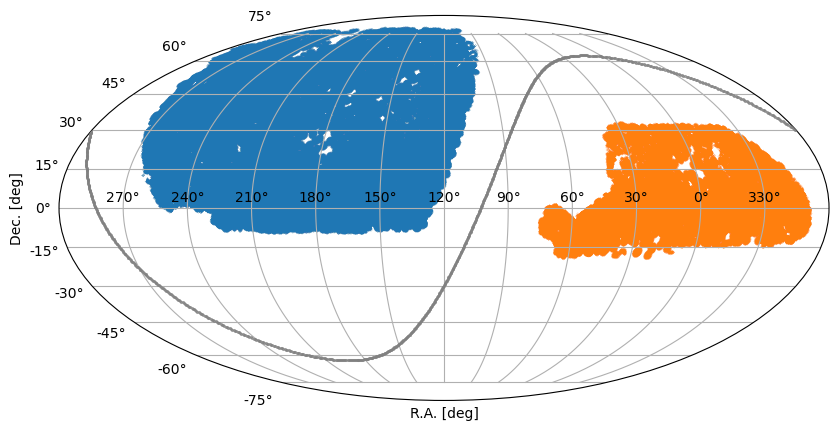

In [21]:
ax = desiplots.init_sky(projection='mollweide', ra_center=120, galactic_plane_color='gray', ax=None, ecliptic_plane_color=None)
ax.scatter(ax.projection_ra(Tb_altMTL_join['RA_1'][altmtl_NGC]), ax.projection_dec(Tb_altMTL_join['DEC_1'][altmtl_NGC]), s=0.01, alpha=0.1)
ax.scatter(ax.projection_ra(Tb_altMTL_join['RA_1'][altmtl_SGC]), ax.projection_dec(Tb_altMTL_join['DEC_1'][altmtl_SGC]), s=0.01, alpha=0.1)
